In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np


mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)
X, y = mnist["data"], mnist["target"]
X = X.astype(np.float32) / 255.0
y = y.astype(np.int64)
# scale to [0, 1]
X_trainval, X_test, y_trainval, y_test = train_test_split(
X, y, test_size=10000, random_state=42, stratify=y
)


# MLP Model

In [2]:
import os
import torch
from torch import nn

class MLP_Model(nn.Module):
    def __init__(self):
        super(MLP_Model, self).__init__()
        self.input = nn.Linear(784,2 * 784 )
        self.hidden = nn.Linear(2*784, 2*784)
        self.output = nn.Linear(2*784, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input(x))
        x = self.relu(self.hidden(x))
        x = self.output(x)

        return x


os.makedirs('Models/lr', exist_ok=True)

# optuna for Learning Rate

In [3]:
import optuna
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset
from sklearn.model_selection import KFold

# --- Data ---
X_trainval_tensor = torch.from_numpy(X_trainval).float()
y_trainval_tensor = torch.from_numpy(y_trainval).long()
dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_SPLITS = 5
N_EPOCHS = 10
BATCH    = 1024


def _train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        criterion(model(X), y).backward()
        optimizer.step()

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss

def objetive_lr(trial:optuna.Trial) -> float:
    lr = trial.suggest_float("learning_rate", 1e-5, 5e-1, log=True)

    criterion = nn.CrossEntropyLoss()
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    fold_loss = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval_tensor)):
        train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BATCH, shuffle=True)
        val_loader = DataLoader(Subset(dataset, val_idx), batch_size=len(val_idx), shuffle=False)

        model = MLP_Model().to(DEVICE)
        optimizer = optim.SGD(model.parameters(), lr=lr)

        for epoch in range(N_EPOCHS):
            _train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, criterion=criterion)

        fold_loss.append(_calculate_val_loss(model=model, loader=val_loader, criterion=criterion))

    return float(np.mean(fold_loss))

study = optuna.create_study(direction="minimize")
study.optimize(objetive_lr, n_trials=25, show_progress_bar=True)

print("Best parameters:", study.best_params)
print("Mean avg val loss CV: ", study.best_value)

[I 2026-03-29 20:46:09,788] A new study created in memory with name: no-name-59bbc8d8-f7fb-4d05-b8e9-cecf108a2d01


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-03-29 20:46:52,652] Trial 0 finished with value: 0.34886871576309203 and parameters: {'learning_rate': 0.04794544221582234}. Best is trial 0 with value: 0.34886871576309203.
[I 2026-03-29 20:47:44,562] Trial 1 finished with value: 0.4795504450798035 and parameters: {'learning_rate': 0.02477695710467949}. Best is trial 0 with value: 0.34886871576309203.
[I 2026-03-29 20:48:21,425] Trial 2 finished with value: 0.3576981723308563 and parameters: {'learning_rate': 0.04491904012844043}. Best is trial 0 with value: 0.34886871576309203.
[I 2026-03-29 20:48:57,902] Trial 3 finished with value: 1.3290887594223022 and parameters: {'learning_rate': 0.009024412767967541}. Best is trial 0 with value: 0.34886871576309203.
[I 2026-03-29 20:49:38,358] Trial 4 finished with value: 2.21464147567749 and parameters: {'learning_rate': 0.0018361337656863487}. Best is trial 0 with value: 0.34886871576309203.
[I 2026-03-29 20:50:15,038] Trial 5 finished with value: 1.7427724599838257 and parameters: {

# Training Model with new lr

---FOLD 0 ---


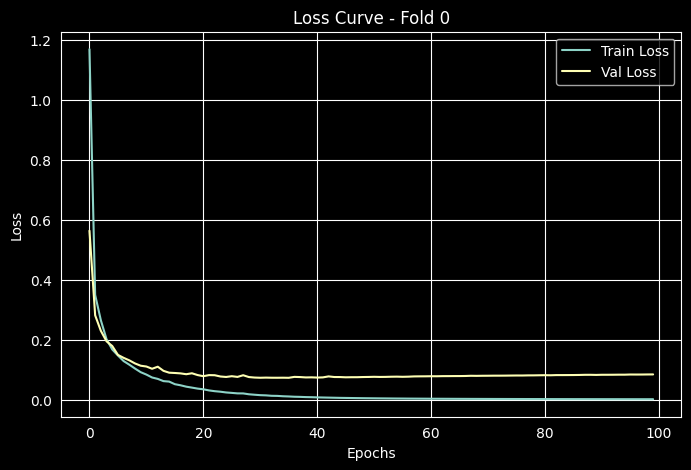

---FOLD 1 ---


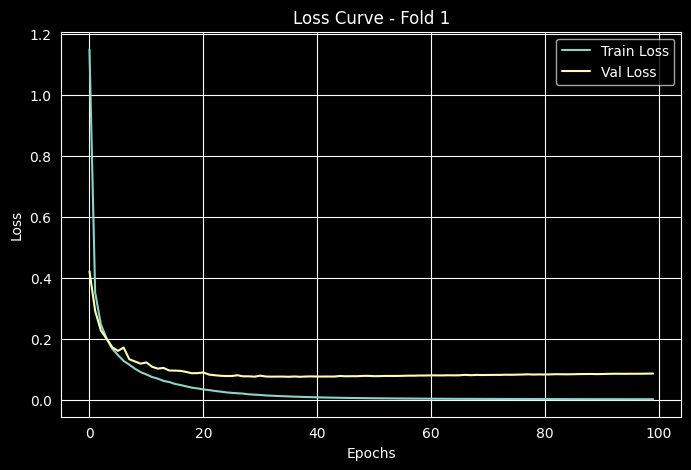

---FOLD 2 ---


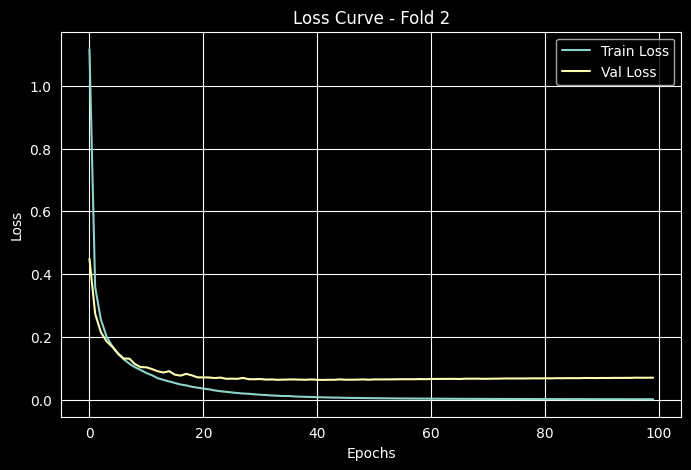

---FOLD 3 ---


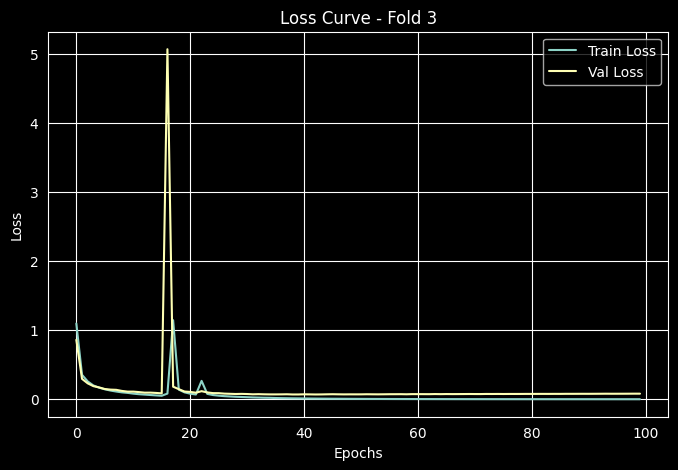

---FOLD 4 ---


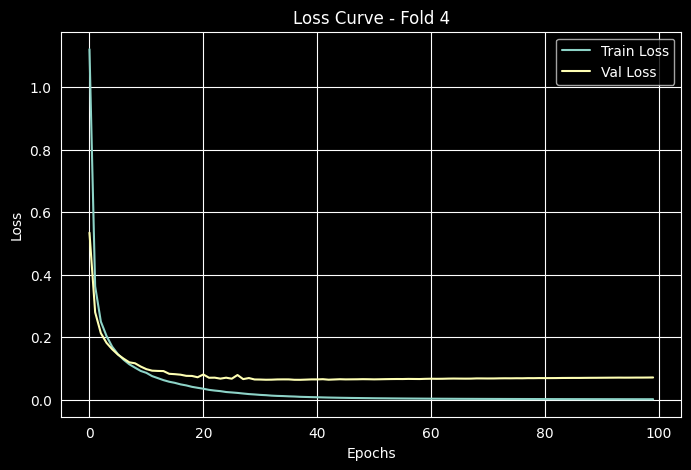

In [4]:
from matplotlib import pyplot as plt

N_EPOCHS = 100

folds = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(folds.split(X_trainval)):
    print(f"---FOLD {fold} ---")

    # Fold Split and Loaders
    train_sample = Subset(dataset, train_index)
    val_sample = Subset(dataset, val_index)

    train_loader = DataLoader(train_sample, batch_size=BATCH, shuffle=True)
    val_loader = DataLoader(val_sample, batch_size=BATCH, shuffle=False)

    #Model, Optimizer and Loss
    model = MLP_Model().to(DEVICE)
    optimizer = optim.SGD(model.parameters(), lr=study.best_params['learning_rate'])
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    history = {'train_loss':[], 'val_loss':[]}

    # Training Loop
    for epoch in range(N_EPOCHS):

        model.train()
        train_running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()

        avg_train_loss = train_running_loss / len(train_loader)

        # Model Validation
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for x,y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                output = model(x)
                loss = criterion(output, y)
                val_running_loss += loss.item()

        avg_val_loss = val_running_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        # Saving Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            checkpoint = {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'history': history
            }
            PATH = os.path.join('Models', 'lr', f'model2_{fold}.pth')
            torch.save(checkpoint, PATH)
            #print(f"Epoch {epoch}: Model Saved with new best loss {avg_val_loss:.4f}")


    # Vizualization
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'Loss Curve - Fold {fold}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Val Loss Comprehension
As it is easy to see witch optimized learning rate models tends to have lower loss. Also, we see that the models after around 40 epoch are not saved (no better model later), for better results we should use so-called scheduler.

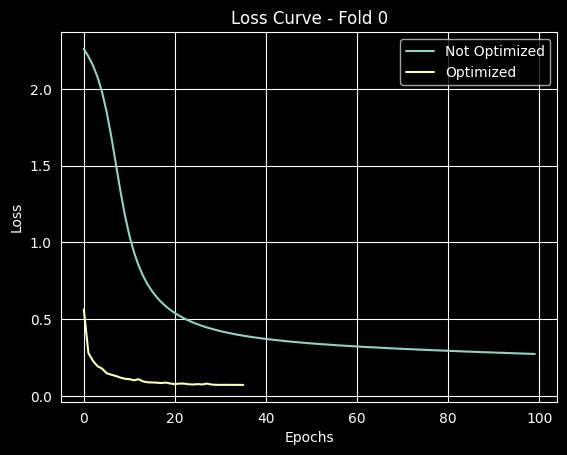

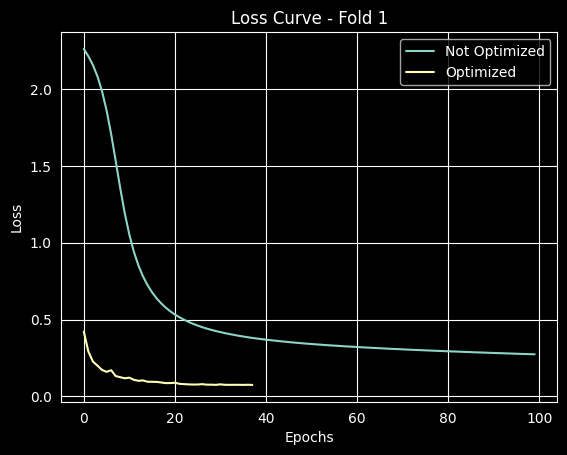

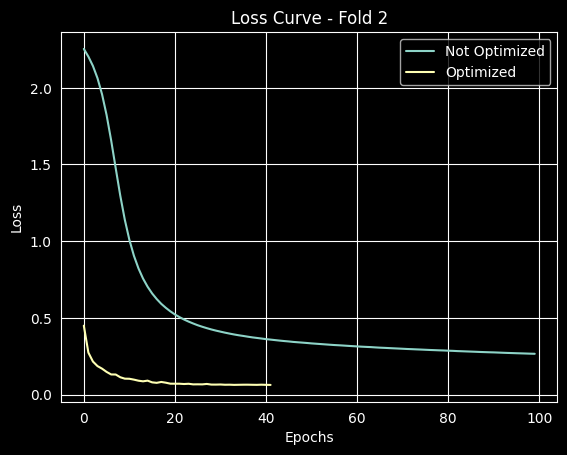

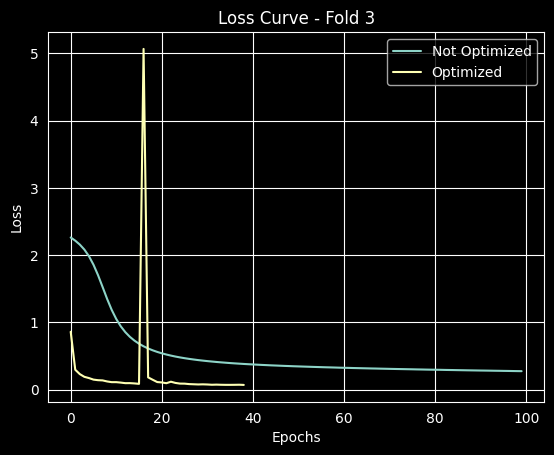

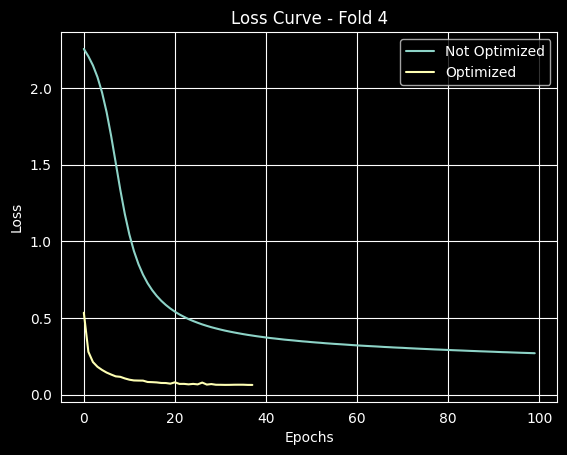

In [6]:
for i in range(5):
    checkpoint1 = torch.load(os.path.join('Models', f'model_{i}.pth'))
    checkpoint2 = torch.load(os.path.join('Models', 'lr', f'model2_{i}.pth'))
    val_loss_not_optimized = checkpoint1['history']['val_loss']
    val_loss_optimized = checkpoint2['history']['val_loss']

    plt.plot(val_loss_not_optimized, label='Not Optimized')
    plt.plot(val_loss_optimized, label='Optimized')
    plt.title(f'Loss Curve - Fold {i}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()